In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('ushape.csv',header=None, names=['X','Y','class'])

In [5]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


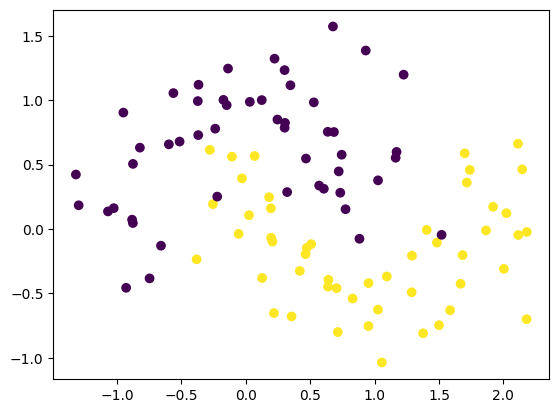

In [6]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [7]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [8]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [9]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

c:\Users\shree\OneDrive\Desktop\Deep-learning\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.get_weights()

[array([[-0.293318  ,  1.2578565 ,  0.9248901 , -1.0002414 , -1.3073698 ,
          0.12855925,  1.8615826 ,  0.5797768 ,  1.042641  , -1.3954026 ],
        [-0.5718299 ,  1.1014177 , -0.20397538, -0.34330612,  0.5341857 ,
          1.6566243 ,  0.09212837, -1.060309  , -0.7759525 ,  2.1256516 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.05083885, -0.3466752 ,  0.25708935, -0.6071317 , -0.040883  ,
          0.3830771 ,  0.13116507,  0.24382691, -0.10346881,  0.48173106],
        [-0.14403947,  0.13554573, -0.3594588 ,  0.11539745, -0.8549752 ,
          0.41396677,  0.57184386,  0.43245003, -0.87284243, -0.549067  ],
        [-0.48750755,  0.4386114 ,  0.36288533, -0.24498664,  0.03503855,
         -0.31249186, -0.50737375, -0.03237233,  0.14105563, -0.33988512],
        [ 0.29537457, -0.27317557, -0.22239839, -0.15506433,  0.19743738,
         -0.69568115,  0.72499645,  0.09275316, -0.12307856, -0.4396689 ],
        [-0.04544

In [11]:
initial_weights = model.get_weights()

In [12]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [13]:
model.set_weights(initial_weights)

In [14]:
model.get_weights()

[array([[ 0.3089006 ,  0.3350447 ,  1.0794132 , -0.65413576, -0.5624053 ,
         -0.28843698,  0.42508882,  0.66509426,  0.7060387 ,  0.4504412 ],
        [-1.2168895 ,  0.9843552 , -0.7147031 ,  0.3287805 ,  0.23518555,
          0.86130905, -0.07084785, -0.0161066 , -0.255329  , -0.42024326]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.13577254,  0.86681396,  0.21790482, -0.47265202, -0.30280557,
         -0.4248217 ,  0.16444285, -0.00280103, -0.15595323,  0.40820563],
        [-0.617822  ,  0.13904049, -0.23771963, -0.04320784, -0.20958191,
          0.40309677,  0.27095702,  0.10669666, -0.21232347, -0.05359577],
        [ 0.18981822, -0.6623194 , -0.41026434,  0.3282557 ,  0.3051415 ,
          0.09392643,  0.07044037, -0.0396079 , -0.2982428 ,  0.20997156],
        [-0.23691961,  0.22482161, -0.03654389, -0.00589597,  0.28334728,
         -0.09396059, -0.48450887,  0.37183517,  0.03082728,  0.38024354],
        [ 0.11546

In [15]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [16]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.6875 - loss: 0.6232 - val_accuracy: 0.6000 - val_loss: 0.6279
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6875 - loss: 0.6148 - val_accuracy: 0.6000 - val_loss: 0.6177
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6750 - loss: 0.6059 - val_accuracy: 0.6000 - val_loss: 0.6081
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7125 - loss: 0.5980 - val_accuracy: 0.6000 - val_loss: 0.5989
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7250 - loss: 0.5894 - val_accuracy: 0.6500 - val_loss: 0.5900
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7250 - loss: 0.5812 - val_accuracy: 0.6500 - val_loss: 0.5805
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7375 - loss: 0.5731 - val_accuracy: 0.7000 - val_loss: 0.5703
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7375 - loss: 0.5654 - val_accuracy: 0.7500 - val_loss

In [17]:
model.get_weights()

[array([[ 0.4280568 ,  0.36014646,  1.1485298 , -0.89792675, -0.64262146,
         -0.2831278 ,  0.4477879 ,  0.6354467 ,  0.78596246,  0.5917603 ],
        [-1.1457947 ,  1.1224012 , -0.8674443 ,  0.30941534,  0.16989101,
          0.9715671 , -0.2346557 , -0.14208925, -0.39584988, -0.2559382 ]],
       dtype=float32),
 array([ 0.11464809,  0.09931805,  0.03769205,  0.02504155, -0.04143216,
        -0.02792302, -0.05979574, -0.08051659,  0.02266586,  0.11036947],
       dtype=float32),
 array([[ 1.47122983e-02,  7.98802078e-01,  8.07983205e-02,
         -3.43042880e-01, -1.65348172e-01, -4.92418736e-01,
          2.81906903e-01, -8.15127268e-02, -2.58284628e-01,
          5.46853542e-01],
        [-5.52638471e-01,  2.23573267e-01, -3.63969862e-01,
         -1.54327363e-01, -2.91885823e-01,  5.56643486e-01,
          3.94231290e-01,  2.39008889e-01, -2.12592363e-01,
         -1.50266737e-01],
        [ 3.23778123e-01, -7.30986714e-01, -5.88177145e-01,
          4.18296158e-01,  3.98422

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 802us/step


<Axes: >

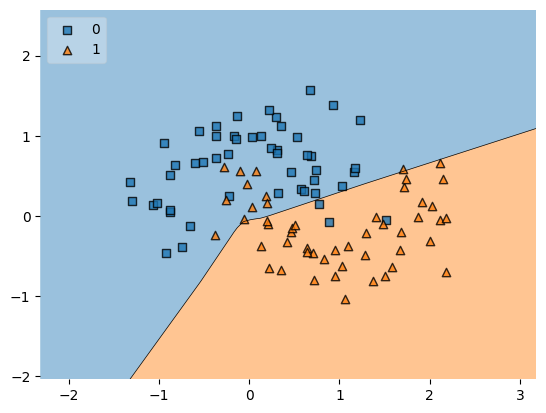

In [18]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

In [19]:
(np.random.randn(10,10)*0.01).min()

np.float64(-0.021895467057488044)

In [20]:
(np.random.randn(10,10)*0.01).max()

np.float64(0.023192640104894264)